# BMI 6015 - Final Project
## Machine Learning Driven Heart Disease Detection in Patients

Author: Jack Doughty, u1330615

#### Problem statement: 
Heart disease is one of the leading causes of mortality worldwide. Early diagnosis is crucial for effective management and treatment, but identifying heart disease can be challenging due to its diverse symptoms, which may range from chest pain and shortness of breath to less obvious signs like fatigue and dizziness. Often, these symptoms overlap with those of less severe conditions, making accurate diagnosis difficult without comprehensive medical assessments. The challenge lies in the fact that traditional diagnostic methods, such as clinical evaluations, stress tests, and invasive procedures, can be time-consuming, costly, and require significant medical expertise. As a result, there is a pressing need for more accessible, accurate, and efficient diagnostic tools that can support healthcare professionals in identifying heart disease at an early stage. This project aims to address this problem by utilizing supervised and unsupervised machine learning models to analyze patient data and predict the presence of heart disease. By training algorithms like Support Vector Machines (SVM), K-Nearest Neighbors (KNN), and Naive Bayes on key patient metrics (age, cholesterol levels, blood pressure, ECG results, etc.), we can develop predictive models that provide reliable assessments based on non-invasive data. Similarly, unsupervised machine learning algorithms can be used to identify groups of patients with similar health profiles, which might reveal distinct risk patterns, atypical conditions, and correlations between features. 



#### Objectives:

The objective of this project is to develop a robust predictive model for diagnosing heart disease by training and evaluating a combination of supervised and unsupervised machine learning algorithms on patient health data. Using Support Vector Machines (SVM), K-Nearest Neighbors (KNN), and Naive Bayes, the project aims to classify patients based on their likelihood of having heart disease, leveraging features such as age, cholesterol, blood pressure, and other clinical indicators. To ensure the accuracy and generalizability of these models, k-fold cross-validation will be employed, allowing the evaluation of model performance across different subsets of the data and reducing the risk of overfitting. Additionally, Optuna will be used to tune hyperparameters, optimizing the models for better accuracy and efficiency. By comparing these supervised models, the goal is to identify the most accurate and reliable approach for early diagnosis, potentially aiding healthcare professionals in diagnosing patients with heart disease without invasive procedures. The project will also utilize three unsupervised learning algorithms to explore hidden patterns, group patients with similar risk profiles, and detect outliers that may indicate rare or severe conditions. Ultimately, this comprehensive approach seeks to improve the prediction of heart disease and identify correlations between patient metrics using both supervised and unsupervised machine learning techniques, leading to more personalized treatment strategies and enhanced preventive care.

#### Dataset(s): https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data/dataLinks

The dataset consists of medical records for patients, with a total of 303 rows. It includes various clinical and demographic features that are commonly used to assess cardiovascular health. These features include attributes like age, resting blood pressure (trestbps), serum cholesterol levels (chol), maximum heart rate achieved (thalch), and other diagnostic indicators such as chest pain type (cp), fasting blood sugar (fbs), and electrocardiographic results (restecg). Additionally, there are categorical features like exercise-induced angina (exang) and the number of major vessels colored by fluoroscopy (ca). The target variable (num) indicates the presence and severity of heart disease, ranging from 0 (no disease) to higher values representing more severe conditions. It should be noted that the dataset does contain some data quality issues. There are zero values in features like cholesterol, fasting blood sugar, and exercise-induced angina, which may not be realistic and could indicate missing or erroneous data. Therefore, some data cleaning and preprocessing would be necessary to ensure the accuracy and reliability of any subsequent analysis or model training. 

### Import the dataset, libraries, and check its contents:

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, silhouette_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.manifold import TSNE
import optuna
import shap
shap.initjs()

import warnings
warnings.filterwarnings(action="ignore")

In [2]:
df = pd.read_csv("/Users/jackdoughty/classes/bmi/project/heart.csv")
df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
5,57,1,0,140,192,0,1,148,0,0.4,1,0,1,1
6,56,0,1,140,294,0,0,153,0,1.3,1,0,2,1
7,44,1,1,120,263,0,1,173,0,0.0,2,0,3,1
8,52,1,2,172,199,1,1,162,0,0.5,2,0,3,1
9,57,1,2,150,168,0,1,174,0,1.6,2,0,2,1


In [3]:
df.shape

(303, 14)

Check data types

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


All data is numerical, no need for feature vectorization

### Data pre-processing and Exploration

Check unique value counts for each feature

In [5]:
for col in df.columns:
    unique_values = df[col].nunique()
    print(f"{col}: {unique_values} unique values")

age: 41 unique values
sex: 2 unique values
cp: 4 unique values
trestbps: 49 unique values
chol: 152 unique values
fbs: 2 unique values
restecg: 3 unique values
thalach: 91 unique values
exang: 2 unique values
oldpeak: 40 unique values
slope: 3 unique values
ca: 5 unique values
thal: 4 unique values
target: 2 unique values


Check for missing values:

In [6]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

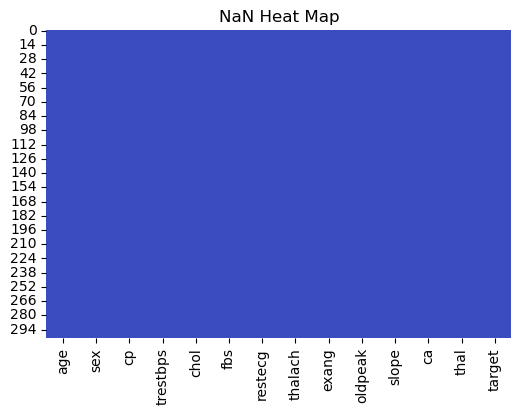

In [7]:
plt.figure(figsize=(6,4))
sns.heatmap(df.isnull(), cbar=False, cmap="coolwarm")
plt.title('NaN Heat Map')
plt.show()

There are no missing values, no need to handle missing data.

Describe Target Variable

target
1    165
0    138
Name: count, dtype: int64


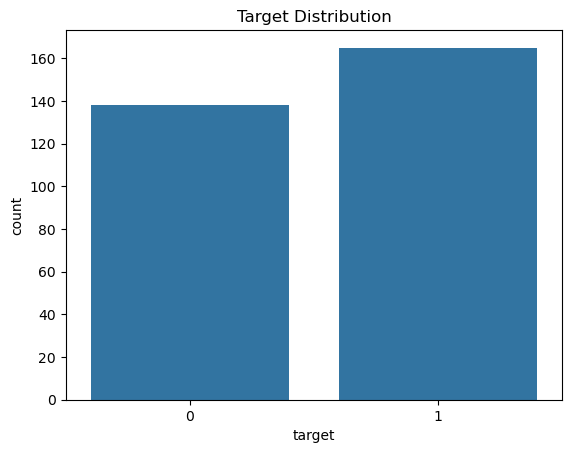

In [8]:
print(df['target'].value_counts())
sns.countplot(x='target', data=df)
plt.title('Target Distribution')
plt.show()

There is a mild imbalance in the target class. Use oversampling on class 0 to correct imbalance.

In [9]:
X = df.drop(columns=['target']) 
y = df['target']

ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)

df = pd.concat([pd.DataFrame(X_resampled, columns=X.columns), pd.DataFrame(y_resampled, columns=['target'])], axis=1)

target
1    165
0    165
Name: count, dtype: int64


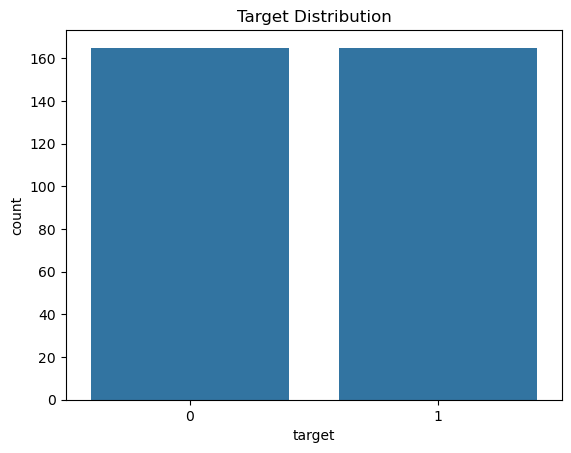

In [10]:
print(df['target'].value_counts())
sns.countplot(x='target', data=df)
plt.title('Target Distribution')
plt.show()

Check correlations:

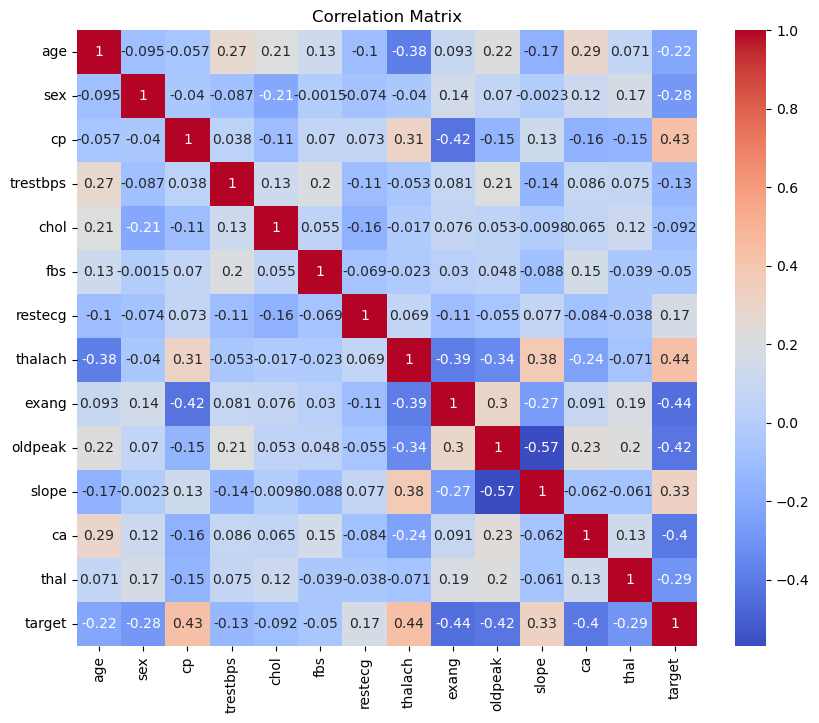

In [11]:
plt.figure(figsize=(10,8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

Moderate positive correlations appear to be between chest pain (cp) and the presence of heart disease (target) as well as maximum heart rate achieved (thalach) and presence of heart disease (target). A very strong negative correlation appears between slope of exercise ST segment (slope) and the ST depression (oldpeak). Though this is to be expected  because as slope increases (less severe to more severe), oldpeak values also increase, reflecting worsening heart conditions. Other correlations are near negligible.

Check for Outliers

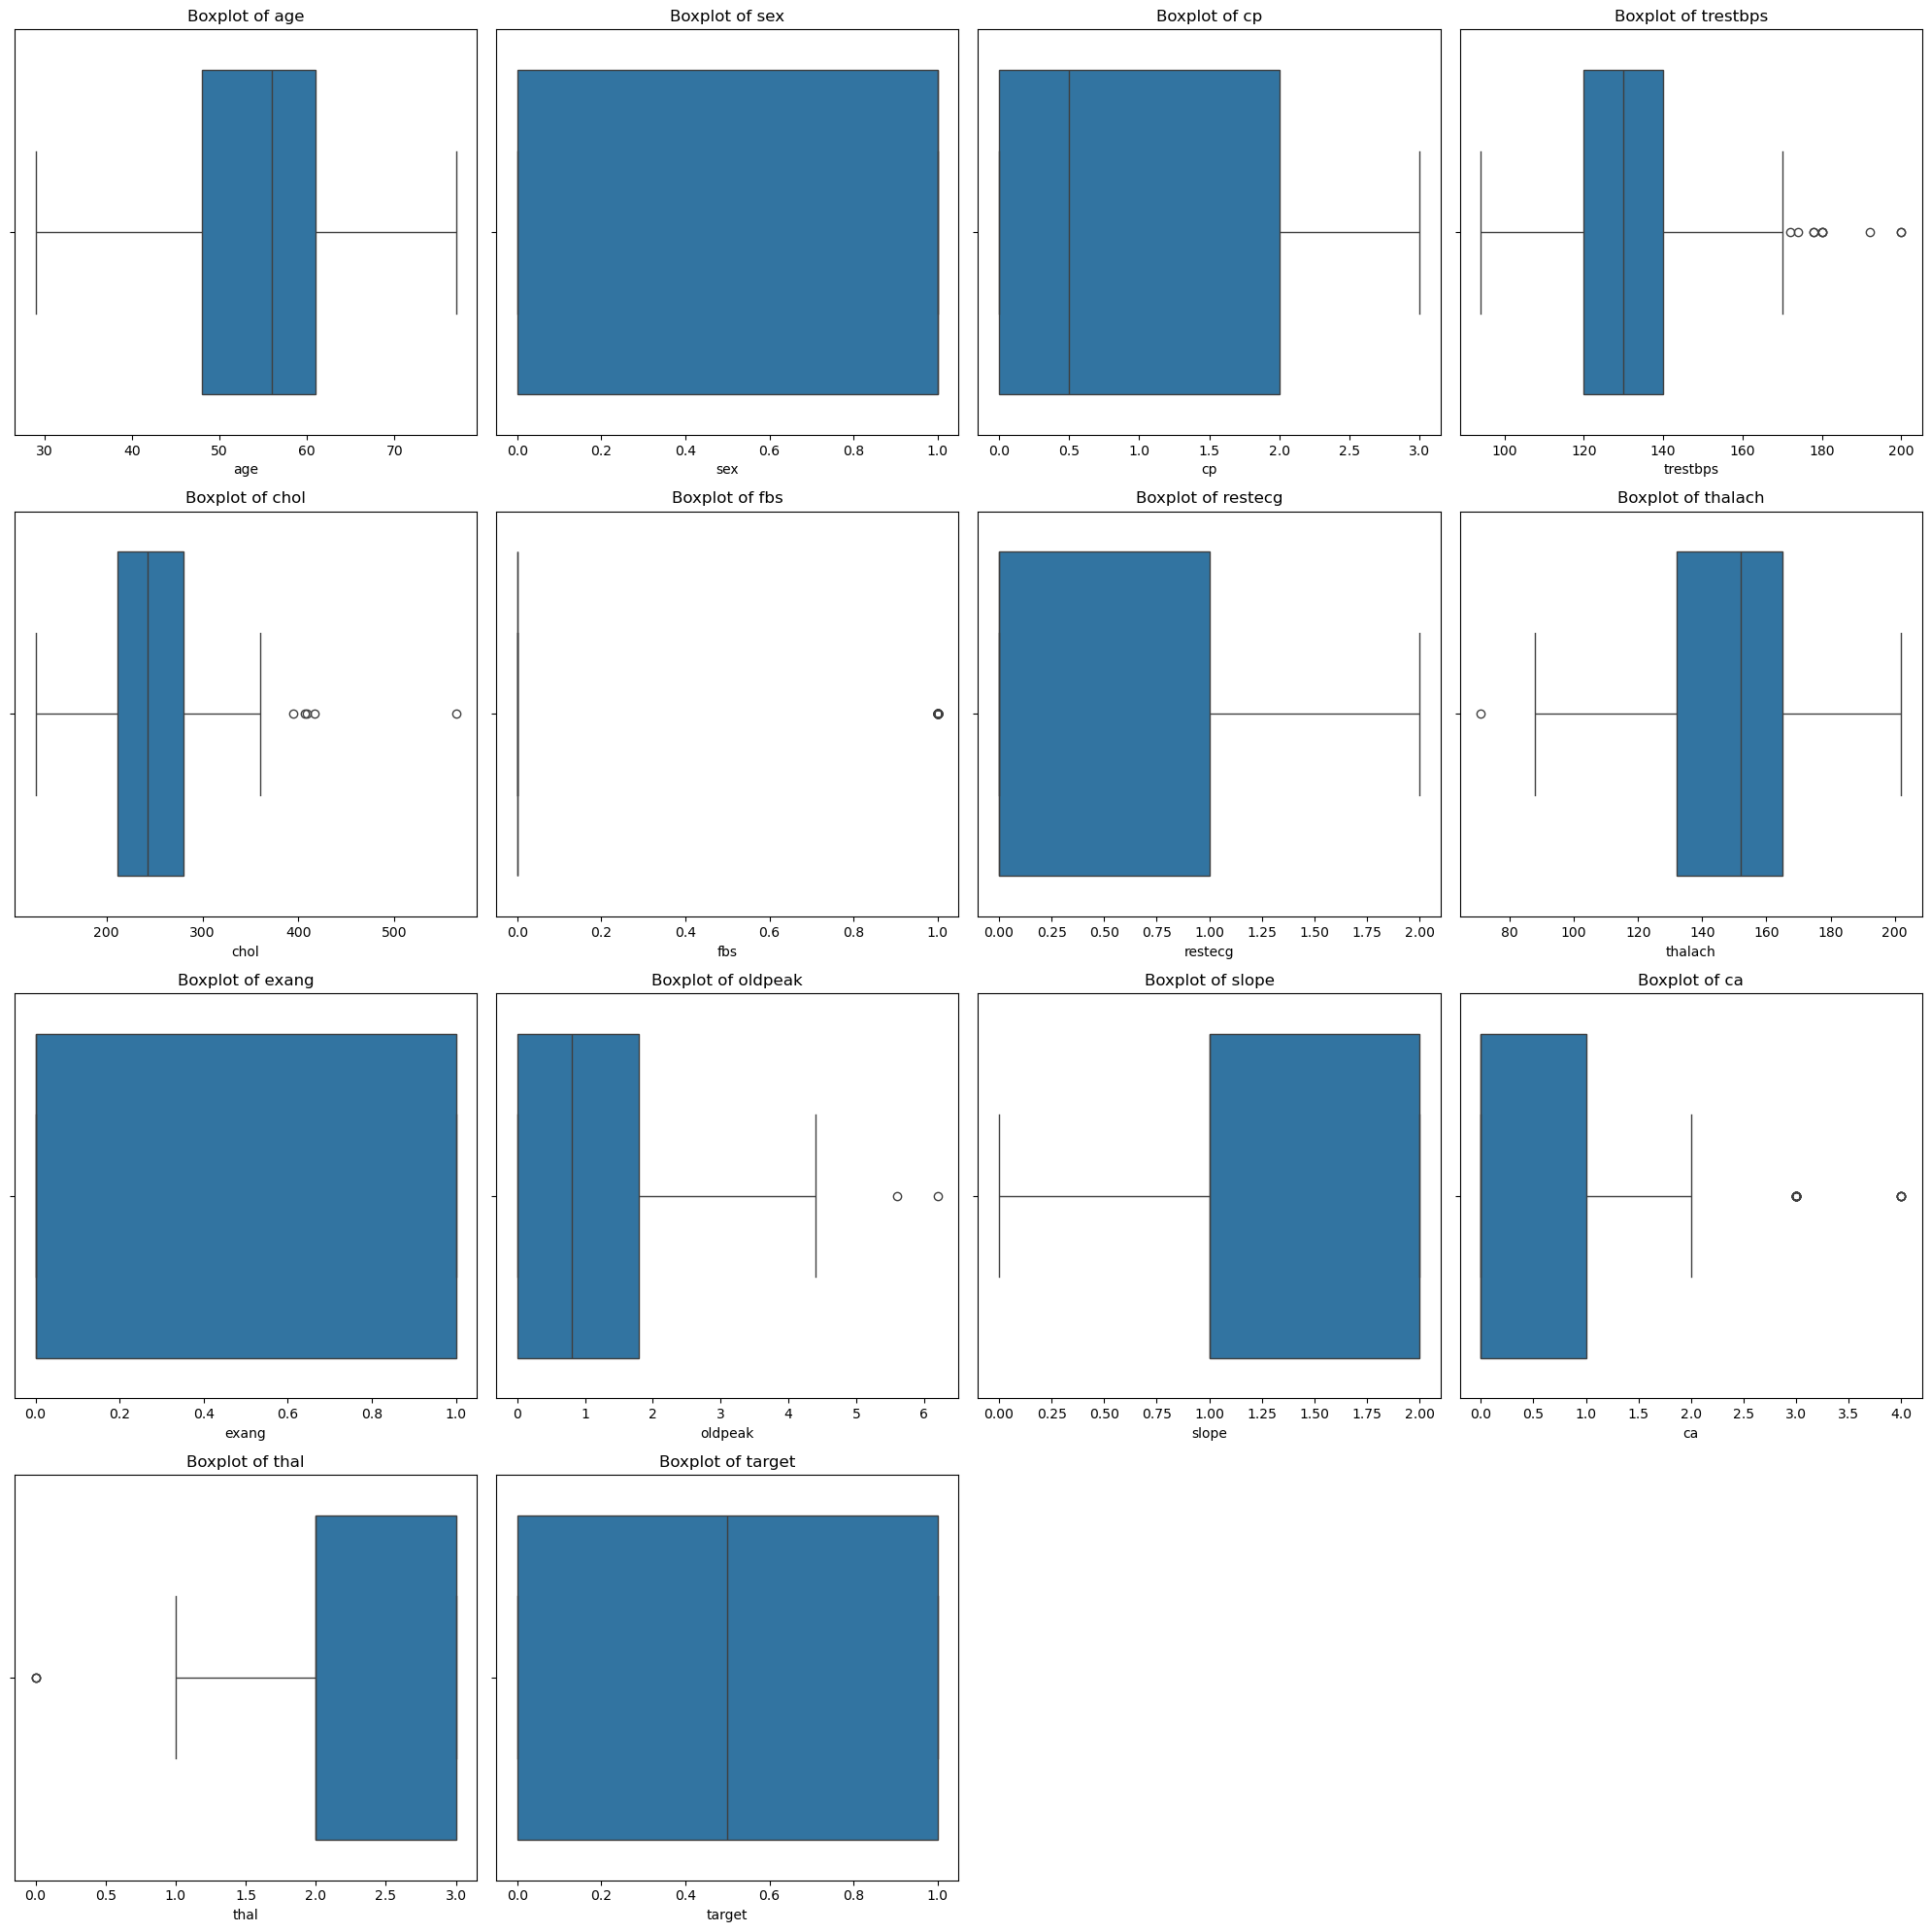

In [12]:
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns

num_cols = len(numerical_columns)
fig, axes = plt.subplots(nrows=(num_cols // 4) + 1, ncols=4, figsize=(20, 5 * ((num_cols // 4) + 1)))

axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

Several outliers in the resting heart rate column but other than that there are few outliers

Generate descriptive statistics

In [13]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,330.000000,330.000000,330.000000,330.000000,330.000000,330.000000,330.000000,330.000000,330.000000,330.000000,330.000000,330.000000,330.000000,330.000000
mean,54.445455,0.693939,0.927273,131.654545,246.990909,0.157576,0.506061,148.469697,0.351515,1.072121,1.393939,0.784848,2.306061,0.500000
std,9.008527,0.461555,1.040596,17.623263,51.990500,0.364896,0.524442,22.991488,0.478168,1.168434,0.615869,1.042740,0.628811,0.500759
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,0.500000,130.000000,243.000000,0.000000,0.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,0.500000
75%,61.000000,1.000000,2.000000,140.000000,280.250000,0.000000,1.000000,165.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


This data will need to be scaled in order to ensure all features are on a similar scale, preventing features with larger values from dominating the learning process and allowing for more accurate model training

Split dataset into training and test sets

In [14]:
X = df.drop(columns=['target']) 
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=81701)

## Train Supervised Models

3 Supervised Models are trained for classifying presence or abscence of heart disease in patients. These models are:

1.) SVM (Support Vector Machine)

2.) KNN (K-Nearest Neighbors)

3.) Naive Bayes

### SVM

Create the objective function for Optuna with K-fold cross validation.

In [15]:
def objective(trial):
    C = trial.suggest_float('svc__C', 0.1, 10.0, log=True)
    gamma = trial.suggest_float('svc__gamma', 0.001, 10, log=True)  
    kernel = trial.suggest_categorical('svc__kernel', ['linear', 'rbf'])
   
    #Create pipeline
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', SVC(
            C=C,
            gamma=gamma,
            kernel=kernel
        ))
    ])

    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=81701)
    scores = cross_val_score(pipe, X_train, y_train, cv=kfold, scoring='accuracy')

    return scores.mean()

Create the optuna study and then optimize

In [16]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)
print("Best Parameters:", study.best_params)
print("Best Cross-Validation Accuracy:", study.best_value)

Best Parameters: {'svc__C': 0.7379839067937711, 'svc__gamma': 0.05128096333574939, 'svc__kernel': 'rbf'}
Best Cross-Validation Accuracy: 0.8635703918722786


Train the model with the best parameters using pipeline on the full training set

In [17]:
best_params = study.best_params

#Create pipeline
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', SVC(
        C=best_params['svc__C'],
        gamma=best_params['svc__gamma'],
        kernel=best_params['svc__kernel']
    ))
])
pipe.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('knn', SVC(C=0.7379839067937711, gamma=0.05128096333574939))])

Evaluate Model

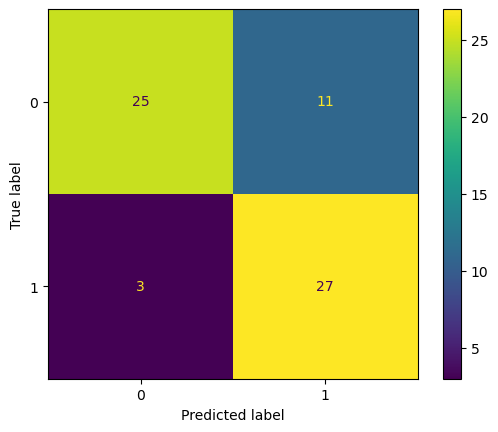

In [18]:
y_pred = pipe.predict(X_test)

cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipe.classes_)
disp.plot()

In [19]:
accuracy_svm = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy_svm)

precision_svm = precision_score(y_test, y_pred)
print("Precision:", precision_svm)

recall_svm = recall_score(y_test, y_pred)
print("Recall:", recall_svm)

f1_svm = f1_score(y_test, y_pred)
print("F1 Score:", f1_svm)

Accuracy: 0.7878787878787878
Precision: 0.7105263157894737
Recall: 0.9
F1 Score: 0.7941176470588235


Use SHAP to explain and interpret the obtained results.

Using 264 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/66 [00:00<?, ?it/s]

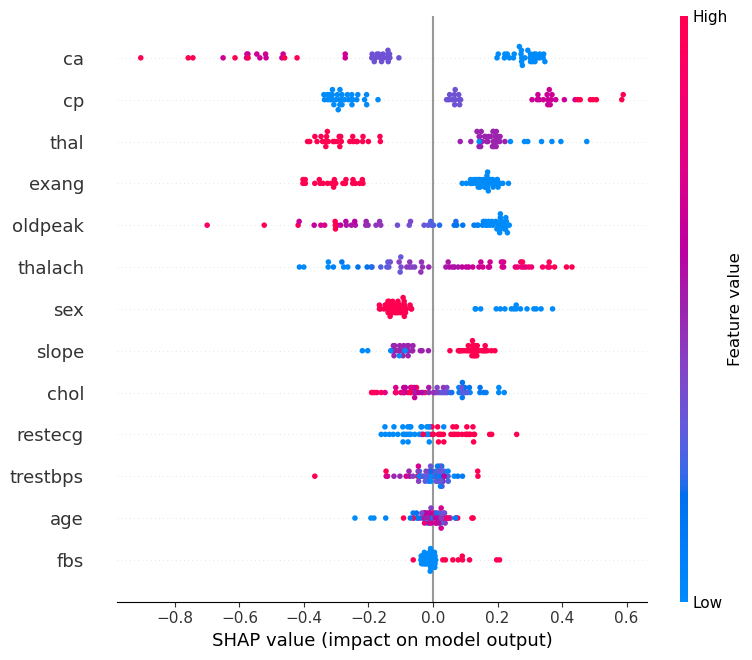

In [20]:
def model_predict(data_asarray):
    data_asframe = pd.DataFrame(data_asarray, columns=X.columns)
    return pipe.decision_function(data_asframe)  # Use decision_function for SVM

shap_kernel_explainer = shap.KernelExplainer(model_predict, X_train)

shap_values = shap_kernel_explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, feature_names=list(X.columns))

Key Takeaways
    
    •	The most important features driving the model’s decisions are ca, cp, thal, and exang.
	•	High values of ca and thal increase the likelihood of disease.
	•	High thalach (heart rate) reduces the likelihood of disease.
	•	The model relies on a few key features for its predictions, with less emphasis on fbs and age.

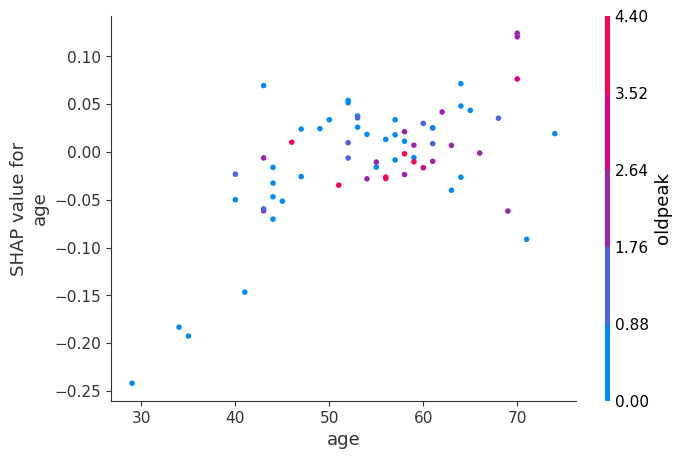

In [21]:
shap.dependence_plot("age", shap_values, X_test)

This plot highlights that age somewhat influences the model’s prediction, especially in combination with ST depression (oldpeak).

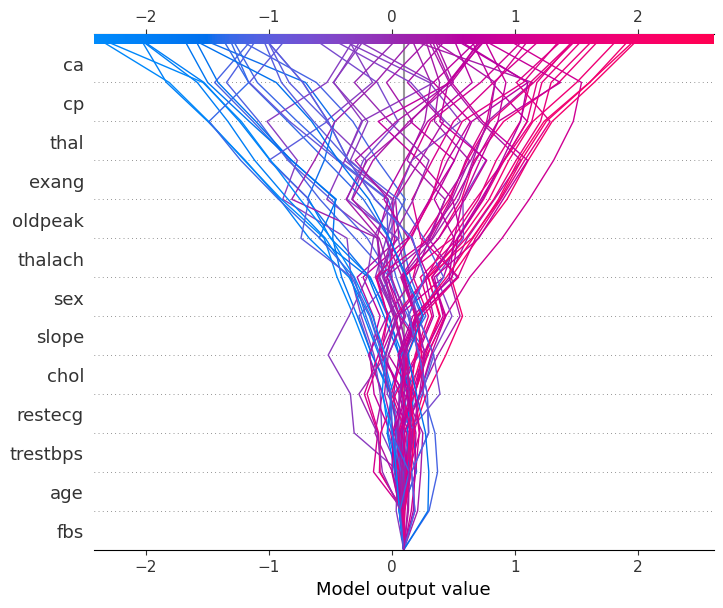

In [22]:
shap.decision_plot(
    shap_kernel_explainer.expected_value,
    shap_values,
    X_test,
    feature_names=list(X.columns)  # Ensure feature_names is a list
)

ca, cp, and exang (top-ranked features) have the largest cumulative impact on the predictions. Their influence can either increase or decrease the model output significantly.

### KNN

Create the objective function for Optuna and use K-Fold Cross validation in order to find best model possible.

In [39]:
def objective(trial):
    n_neighbors = trial.suggest_int('n_neighbors', 3, 15)
    weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
    metric = trial.suggest_categorical('metric', ['euclidean', 'manhattan', 'minkowski'])
    
    #Create pipeline
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(
            n_neighbors=n_neighbors,
            weights=weights,
            metric=metric
        ))
    ])

    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=81701)
    scores = cross_val_score(pipe, X_train, y_train, cv=kfold, scoring='accuracy')

    return scores.mean()

Create the optuna study and then optimize

In [40]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)
print("Best Parameters:", study.best_params)
print("Best Cross-Validation Accuracy:", study.best_value)

Best Parameters: {'n_neighbors': 13, 'weights': 'distance', 'metric': 'manhattan'}
Best Cross-Validation Accuracy: 0.8786647314949201


Train the best pipeline on the full training set

In [41]:
best_params = study.best_params
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(
        n_neighbors=best_params['n_neighbors'],
        weights=best_params['weights'],
        metric=best_params['metric']
    ))
])
pipe.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('knn',
                 KNeighborsClassifier(metric='manhattan', n_neighbors=13,
                                      weights='distance'))])

Evaluate Model

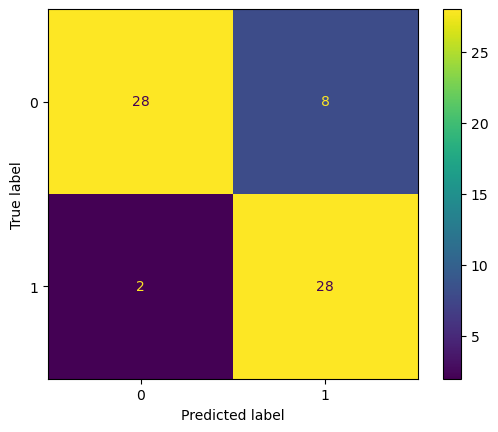

In [42]:
y_pred = pipe.predict(X_test)

cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipe.classes_)
disp.plot()

In [43]:
accuracy_knn = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy_knn)

precision_knn = precision_score(y_test, y_pred)
print("Precision:", precision_knn)

recall_knn = recall_score(y_test, y_pred)
print("Recall:", recall_knn)

f1_knn = f1_score(y_test, y_pred)
print("F1 Score:", f1_knn)

Accuracy: 0.8484848484848485
Precision: 0.7777777777777778
Recall: 0.9333333333333333
F1 Score: 0.8484848484848485


Use SHAP to explain and interpret the obtained results.

In [45]:
def model_predict(data_asarray):
    # Convert input array to DataFrame with column names
    data_asframe = pd.DataFrame(data_asarray, columns=X.columns)
    return pipe.predict_proba(data_asframe)  # Use predict_proba for KNN

shap_kernel_explainer = shap.KernelExplainer(model_predict, X_train)

shap_values = shap_kernel_explainer.shap_values(X_test)

Using 264 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/66 [00:00<?, ?it/s]

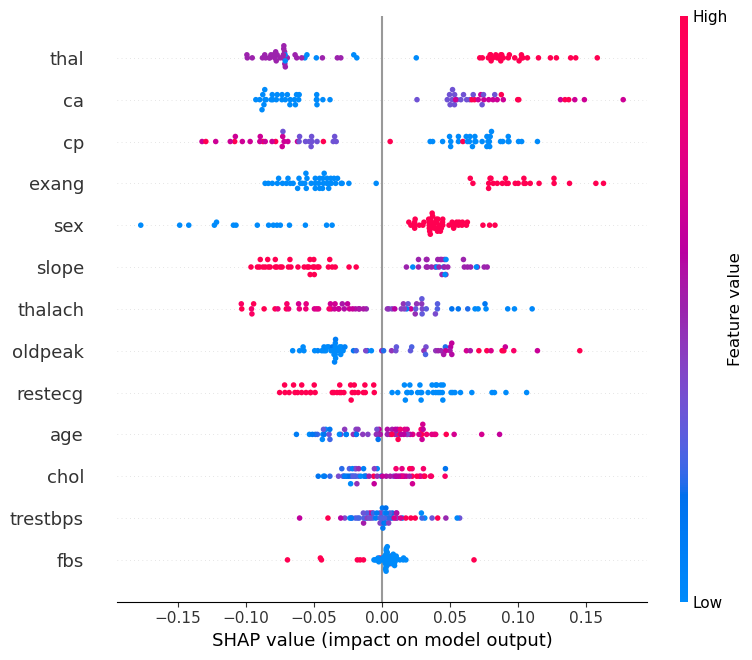

In [62]:
shap_values_all = np.array([shap_values[i][:, 0] for i in range(len(shap_values))])

# Generate SHAP summary plot
shap.summary_plot(
    shap_values_all,  # SHAP values for all instances
    X_test,           # Feature values for all instances
    feature_names=list(X.columns)
)

thal, ca, cp, and exang have the highest impact on the model’s predictions.

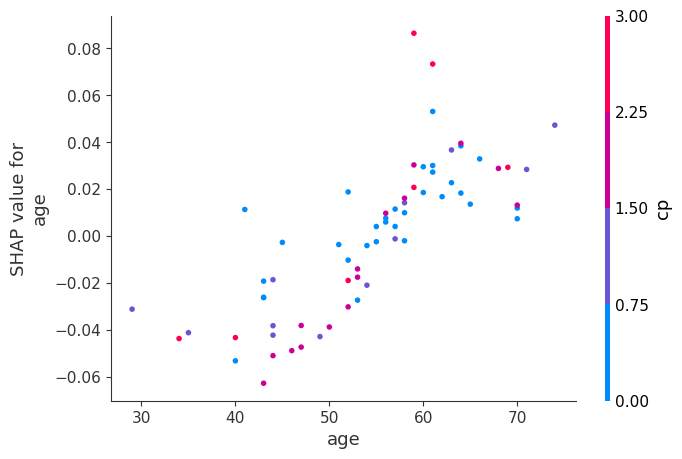

In [64]:
shap.dependence_plot("age", shap_values_all, X_test)

This demonstrates that age influences the model’s prediction in a linear fasion, especially in combination with higher chest pain (cp).

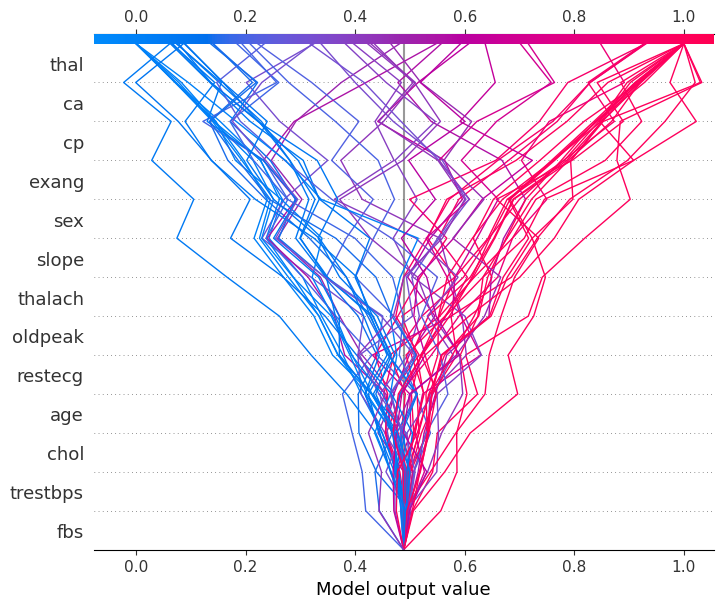

In [70]:
shap.decision_plot(
    shap_kernel_explainer.expected_value[0],  
    shap_values_all,                         
    X_test,                                   
    feature_names=list(X.columns)            
)

	•	Features like thal and ca push predictions toward higher model output values.
	•	thal,ca,and cp dominate the model’s output, showing largest cumulative contributions to predictions.

### Naive Bayes

Create pipleline and perform cross-validation to find best model possible.

In [71]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('nb', GaussianNB())
])

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=81701)
cv_scores = cross_val_score(pipe, X_train, y_train, cv=kfold, scoring='accuracy')

print("Cross-validation scores:", cv_scores)
print("Mean accuracy:", cv_scores.mean())

Cross-validation scores: [0.83018868 0.9245283  0.8490566  0.71698113 0.76923077]
Mean accuracy: 0.8179970972423802


Sufficient Consistency between different folds is observed. Train the model.

In [72]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('nb', GaussianNB())])

Evaluate Model Performance

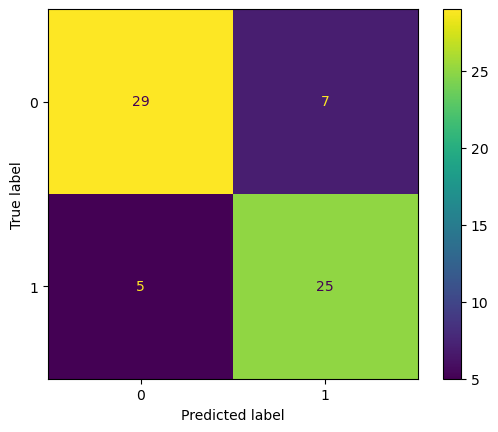

In [73]:
y_pred = pipe.predict(X_test)

cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipe.classes_)
disp.plot()

In [74]:
accuracy_nb = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy_nb)

precision_nb = precision_score(y_test, y_pred)
print("Precision:", precision_nb)

recall_nb = recall_score(y_test, y_pred)
print("Recall:", recall_nb)

f1_nb = f1_score(y_test, y_pred)
print("F1 Score:", f1_nb)

Accuracy: 0.8181818181818182
Precision: 0.78125
Recall: 0.8333333333333334
F1 Score: 0.8064516129032258


Use SHAP to explain and interpret the obtained results.

In [75]:
def model_predict(data_asarray):
    # Convert input array to DataFrame with column names
    data_asframe = pd.DataFrame(data_asarray, columns=X.columns)
    return pipe.predict_proba(data_asframe)  # Use predict_proba for KNN

shap_kernel_explainer = shap.KernelExplainer(model_predict, X_train)

shap_values = shap_kernel_explainer.shap_values(X_test)

Using 264 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/66 [00:00<?, ?it/s]

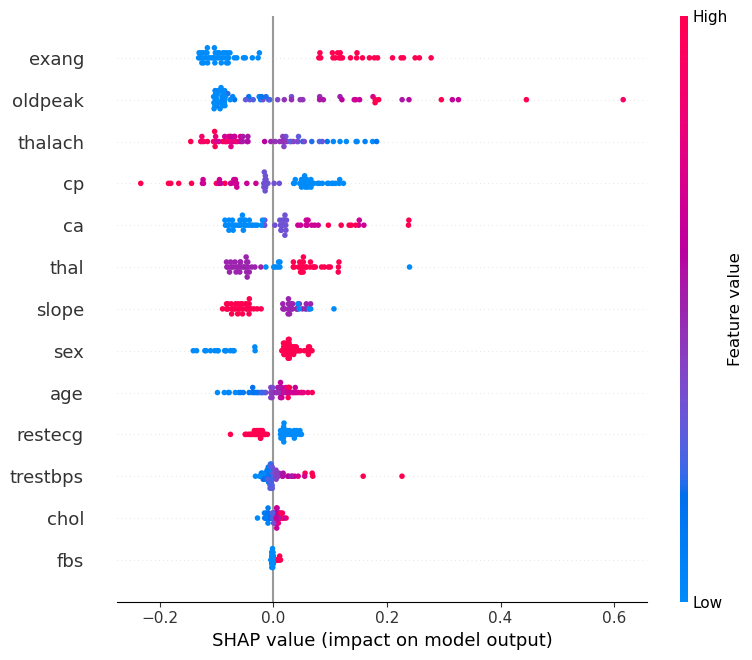

In [77]:
shap_values_all = np.array([shap_values[i][:, 0] for i in range(len(shap_values))])

shap.summary_plot(
    shap_values_all,  # SHAP values for all instances
    X_test,           # Feature values for all instances
    feature_names=list(X.columns)
)

Key features such as exang, oldpeak, and thalach have the most significant impact on predictions, with clear distinctions between high and low feature values influencing the model output.

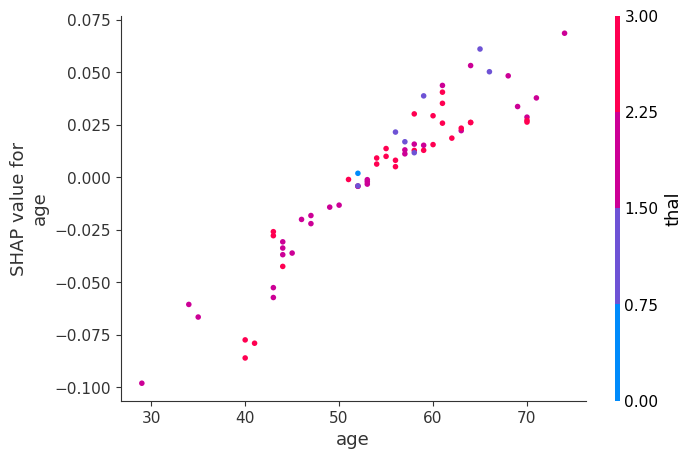

In [78]:
shap.dependence_plot("age", shap_values_all, X_test)

As age increases, its positive impact on predictions grows, especially for higher thal values (thalassemia category), highlighting an interaction between age and thal. There is clearly a strong positive correlation. 

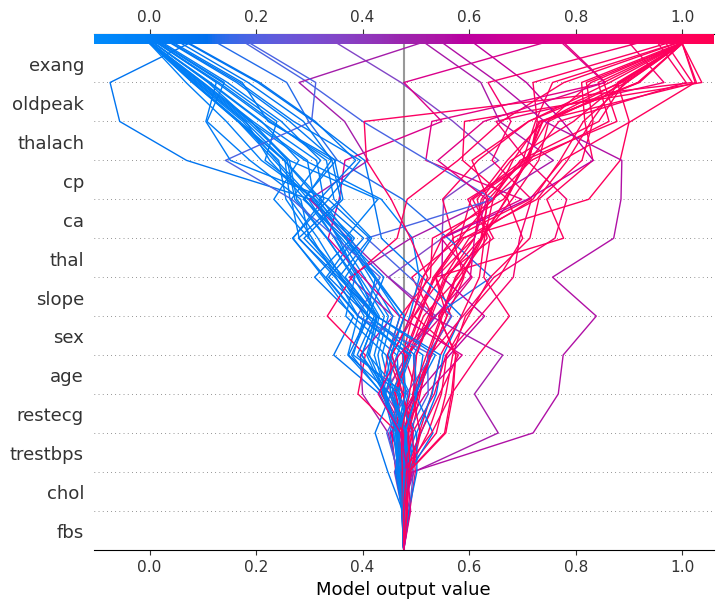

In [79]:
shap.decision_plot(
    shap_kernel_explainer.expected_value[0],  
    shap_values_all,                         
    X_test,                                   
    feature_names=list(X.columns)            
)

Key features like exang, oldpeak, and thalach drive significant cumulative contributions toward predictions, with positive contributions (red) increasing model output and negative contributions (blue) decreasing it, illustrating how these features collectively shape prediction outcomes.

## Train Unsupervised Models


3 Unsupervised Models will be trained for clustering data points and identifying hidden patterns. These models will be:

1.) DBSCAN

2.) K-Means clustering

3.) t-SNE

### DBSCAN

Create the objective function for optuna

In [80]:
def objective(trial):
    eps = trial.suggest_float("eps", 0.3, 10.0, log=True)
    min_samples = trial.suggest_int("min_samples", 1, 5)

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('dbscan', DBSCAN(eps=eps, min_samples=min_samples))
    ])

    pipeline.fit(X_train)
    labels = pipeline.named_steps['dbscan'].labels_

    if len(set(labels)) <= 1:  
        return -1.0
    
    noise_ratio = (labels == -1).sum() / len(labels)
    if noise_ratio > 0.3:  
        return -0.5
    
    return silhouette_score(X_train, labels)

Create the optuna study and then optimize

In [81]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)
print("Best Parameters:", study.best_params)
print("Best Cross-Validation Accuracy:", study.best_value)

Best Parameters: {'eps': 0.31304620368397557, 'min_samples': 1}
Best Cross-Validation Accuracy: 0.1434653777140977


Train the best pipeline on the full training set

In [82]:
best_params = study.best_params
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('dbscan', DBSCAN(eps=best_params['eps'], min_samples=best_params['min_samples']))
])
pipe.fit(X_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('dbscan', DBSCAN(eps=0.31304620368397557, min_samples=1))])

Evaluate Model with Silhouette score

In [83]:
cluster_labels = pipe.named_steps['dbscan'].labels_
silhouette_db = silhouette_score(X_train, cluster_labels)
print(f"Silhouette Score: {silhouette_db:.3f}")

Silhouette Score: 0.143


### K-Means Clustering

Create the objective function for optuna

In [84]:
def objective(trial):
    n_clusters = trial.suggest_int("n_clusters", 1, 20)
    
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('kmeans', KMeans(n_clusters=n_clusters, random_state=42))
    ])
    
    pipe.fit(X_train)
    clusters = pipe.named_steps['kmeans'].predict(X_train)
    
    if len(np.unique(clusters)) > 1:  
        score = silhouette_score(X_train, clusters)
    else:
        score = -1  
    return score

Create the optuna study and then optimize

In [85]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

best_params = study.best_params
print("Best Parameters:", best_params)
print("Best Silhouette Score:", study.best_value)

Best Parameters: {'n_clusters': 4}
Best Silhouette Score: 0.7561191313658064


Train the best pipeline with the full training set

In [86]:
optimal_n_clusters = best_params['n_clusters']
final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=optimal_n_clusters, random_state=42))
])
final_pipeline.fit(X_train)
clusters = final_pipeline.named_steps['kmeans'].predict(X_train)

Evaluate model with Silhouette score

In [87]:
silhouette_km = silhouette_score(X_train, clusters)
print(f"Silhouette Score: {silhouette_km:.4f}")

Silhouette Score: 0.7561


### t-SNE

Create the objective function for optuna

In [88]:
def objective(trial):
    perplexity = trial.suggest_float("perplexity", 5, 50)
    n_iter = trial.suggest_int("n_iter", 250, 1000)
    n_clusters = trial.suggest_int("n_clusters", 2, 10)
    
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('tsne', TSNE(n_components=2, perplexity=perplexity, n_iter=n_iter, random_state=42)),
        ('kmeans', KMeans(n_clusters=n_clusters, random_state=42))
    ])
    
    X_tsne = pipeline.named_steps['scaler'].fit_transform(X)
    X_embedded = pipeline.named_steps['tsne'].fit_transform(X_tsne)
    kmeans = pipeline.named_steps['kmeans']
    clusters = kmeans.fit_predict(X_embedded)
    
    return -kmeans.inertia_

Create the study and then optimize

In [89]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)
print("Best Parameters:", best_params)
print("Best Cross-Validated Silhouette Score:", study.best_value)

Best Parameters: {'n_clusters': 4}
Best Cross-Validated Silhouette Score: -0.008846692740917206


Train the best pipeline with the full training set

In [90]:
best_params = study.best_params
best_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('tsne', TSNE(n_components=2, perplexity=best_params['perplexity'], 
                  n_iter=best_params['n_iter'], random_state=42)),
    ('kmeans', KMeans(n_clusters=best_params['n_clusters'], random_state=42))
])

X_scaled = best_pipeline.named_steps['scaler'].fit_transform(X)
X_embedded = best_pipeline.named_steps['tsne'].fit_transform(X_scaled)
clusters = best_pipeline.named_steps['kmeans'].fit_predict(X_embedded)

Evaluate model with Silhouette score

In [91]:
silhouette_tSNE = silhouette_score(X_embedded, clusters)
print(f"Silhouette Score: {silhouette_tSNE:.4f}")

Silhouette Score: 0.3886


Plot clusters to visualize t-SNE

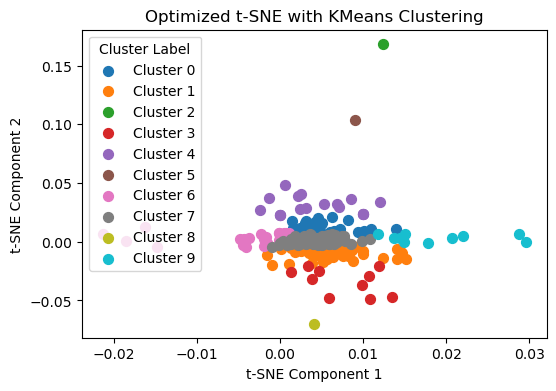

In [92]:
unique_labels = np.unique(clusters)

plt.figure(figsize=(6, 4))
for label in unique_labels:
    plt.scatter(
        X_embedded[clusters == label, 0],
        X_embedded[clusters == label, 1],
        label=f"Cluster {label}",
        s=50
    )

plt.title("Optimized t-SNE with KMeans Clustering")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(title="Cluster Label")
plt.show()

## Best Models

### Supervised Results

In [93]:
data = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "SVM": [accuracy_svm, precision_svm, recall_svm, f1_svm],
    "KNN": [accuracy_knn, precision_knn, recall_knn, f1_knn],
    "Naive Bayes": [accuracy_nb, precision_nb, recall_nb, f1_nb]
}
performance_data= pd.DataFrame(data)

performance_data

,Metric,SVM,KNN,Naive Bayes
0,Accuracy,0.787879,0.848485,0.818182
1,Precision,0.710526,0.777778,0.781250
2,Recall,0.900000,0.933333,0.833333
3,F1 Score,0.794118,0.848485,0.806452


KNN was the best supervised learning algorithm with 0.85 accuracy, 0.77 precision, 0.93 recall and 0.85 F1 score. Though all 3 models performed fairly well with the given data. 

### Unsupervised Results

In [94]:
data = {
    "Metric": ["Silhuoette"],
    "DBSCAN": [silhouette_db],
    "K-Means": [silhouette_km],
    "t-SNE": [silhouette_tSNE]
}
performance_data_unsupervised= pd.DataFrame(data)

performance_data_unsupervised

,Metric,DBSCAN,K-Means,t-SNE
0,Silhuoette,0.143465,0.756119,0.388563


K-means clustering was the best unsupervised learning algorithm with silhouette score = 0.76. The other two models, DBSCAN and t-SNE, significantly underperformed with silhouette scores of just 0.143465 and 0.388563 respectively. This suggests that the clustering is less accurate.

### Conclusion
This project demonstrates the significant potential of machine learning for heart disease diagnosis. By leveraging supervised models such as K-Nearest Neighbors, Support Vector Machines, and Naive Bayes, high accuracy and recall were achieved, with KNN emerging as the most effective model. Unsupervised models provided valuable insights into clustering risk profiles, though results highlight the need for further optimization. Key preprocessing steps, including class balancing, feature scaling, and hyperparameter tuning, were essential for reliable performance. Interpretability tools like SHAP enhanced clinical relevance by identifying critical predictors such as chest pain type and cholesterol levels. While the results are promising, limitations such as dataset generalizability and the challenges of unsupervised clustering underscore the need for external validation and advanced techniques. Future efforts should focus on diverse datasets, temporal analysis, and hybrid modeling to improve robustness and scalability. Overall, this implementation underscores the transformative potential of machine learning in creating accessible, non-invasive, and accurate diagnostic tools for heart disease.
